In [11]:
import sys, pathlib
ROOT = pathlib.Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

IMAGE_PATH = str(ROOT / 'data' / 'sample_image.jpg')
print(f'ROOT = {ROOT}')
print(f'Image : {IMAGE_PATH}')

ROOT = C:\Users\OMAR\Desktop\Solar
Image : C:\Users\OMAR\Desktop\Solar\data\sample_image.jpg


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings('ignore')

import cv2
from PIL import Image

from src.vision import (
    detect_image_format,
    detect_fisheye_disk,
    make_disk_mask,
    mask_sky,
    dual_fisheye_to_equirectangular,
    get_horizon_from_sphere,
    compute_horizon_from_image,
    SINGLE_HALF_RIGHT, SINGLE_HALF_LEFT, DUAL,
)
print('Imports OK')

Imports OK


## 1. Analyse de l'image — détection du format

Dimensions     : 4096 x 2048 px
Format détecté : 'right'
  → single fisheye dans la moitié right


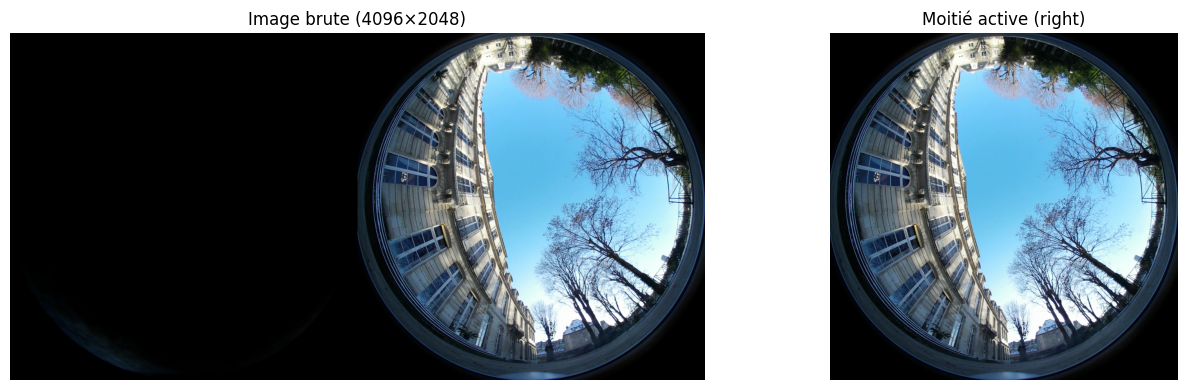

In [13]:
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_rgb.shape[:2]
w_half  = w // 2

fmt = detect_image_format(img_rgb)

print(f'Dimensions     : {w} x {h} px')
print(f'Format détecté : {fmt!r}')
print(f'  → single fisheye dans la moitié {fmt}' if fmt in ('left','right') else '  → dual fisheye')

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(img_rgb)
axes[0].set_title(f'Image brute ({w}×{h})')
axes[0].axis('off')
half = img_rgb[:, w_half:] if fmt == 'right' else img_rgb[:, :w_half]
axes[1].imshow(half)
axes[1].set_title(f'Moitié active ({fmt})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 2. Détection du disque fisheye

Disque détecté : centre=(1023, 1023), rayon=1002 px
Surface disque : 3,154,065 px / 4,194,304 px totaux


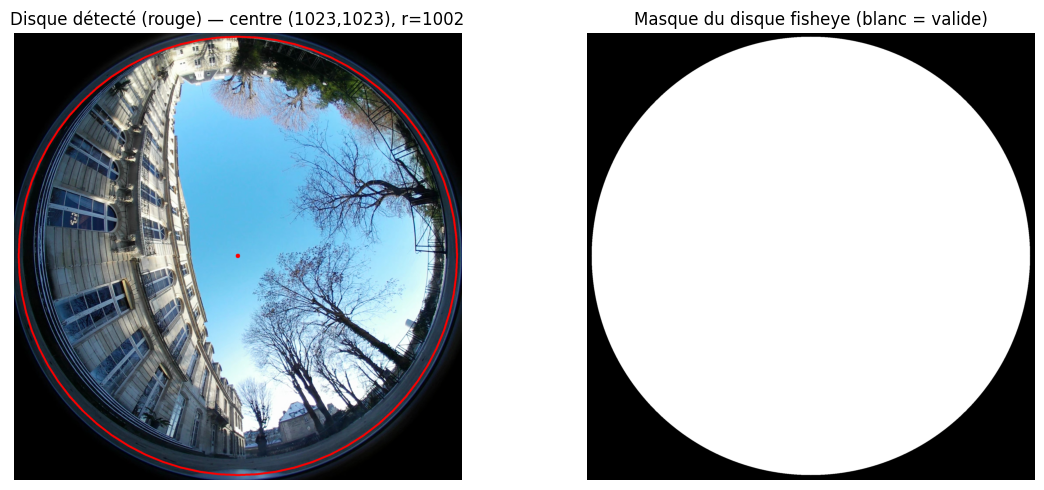

In [5]:
active_half = img_rgb[:, w_half:] if fmt == 'right' else img_rgb[:, :w_half]

cx, cy, r = detect_fisheye_disk(active_half)
disk_mask = make_disk_mask(active_half.shape, cx, cy, r)

print(f'Disque détecté : centre=({cx}, {cy}), rayon={r} px')
print(f'Surface disque : {disk_mask.sum():,} px / {active_half.shape[0]*active_half.shape[1]:,} px totaux')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Dessin du cercle sur l'image
viz = active_half.copy()
cv2.circle(viz, (cx, cy), r, (255, 0, 0), 8)
cv2.circle(viz, (cx, cy), 10, (255, 0, 0), -1)
axes[0].imshow(viz)
axes[0].set_title(f'Disque détecté (rouge) — centre ({cx},{cy}), r={r}')
axes[0].axis('off')

# Masque binaire
axes[1].imshow(disk_mask, cmap='gray')
axes[1].set_title('Masque du disque fisheye (blanc = valide)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. Masquage du ciel — avant/après correction

**Rappel du bug :** MiDaS produit une profondeur *inverse* (grande valeur = objet proche).  
L'ancienne version prenait `depth > threshold` → détectait les objets **proches** comme ciel.  
Les bords noirs (valeur 0, considérés "très lointains") étaient aussi faussement détectés.  
**Fix :** on prend `depth < threshold` ET on masque d'abord le hors-disque.

Calcul du masque ciel (MiDaS + couleur)...
Premier appel : chargement de MiDaS (~30s)


Using cache found in C:\Users\OMAR/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\OMAR/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\OMAR/.cache\torch\hub\intel-isl_MiDaS_master



Pixels ciel dans le disque : 72.6%
Pixels hors-disque dans le masque (doit être 0) : 0


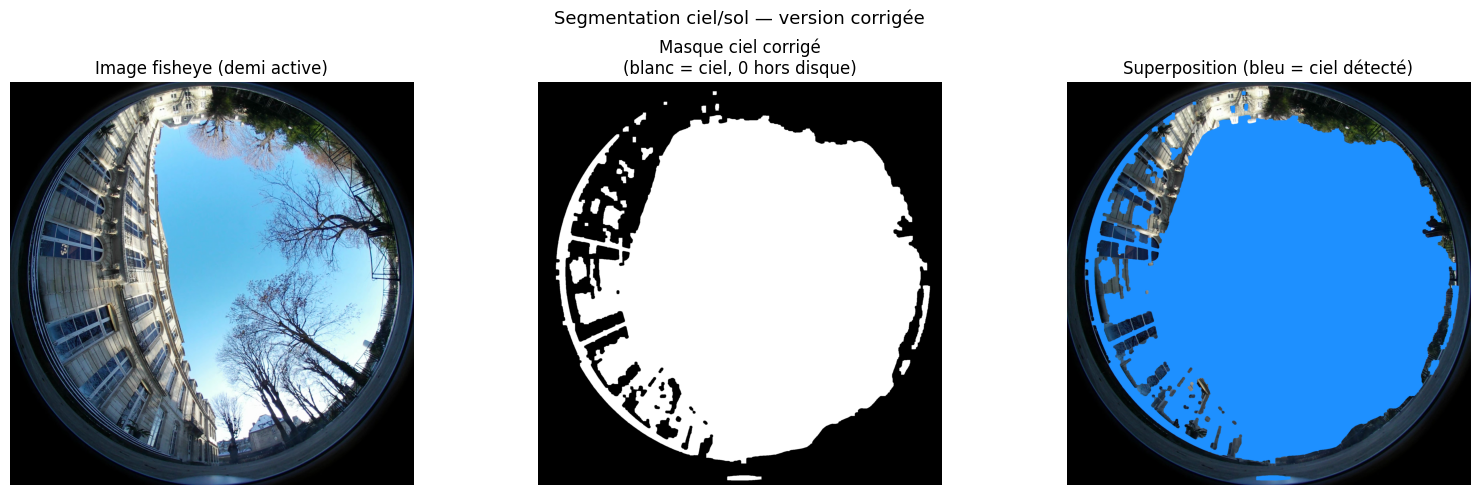

In [6]:
print('Calcul du masque ciel (MiDaS + couleur)...')
print('Premier appel : chargement de MiDaS (~30s)')

sky_mask = mask_sky(
    active_half,
    disk_cx=cx, disk_cy=cy, disk_r=r,
    midas_depth_threshold=0.35,   # ciel = depth < 0.35 (lointain)
    use_color_fallback=True,
    morph_ksize=15,
)

pct_sky = 100 * (sky_mask > 0).sum() / disk_mask.sum()
print(f'\nPixels ciel dans le disque : {pct_sky:.1f}%')
print(f'Pixels hors-disque dans le masque (doit être 0) : {sky_mask[~disk_mask].sum()}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(active_half)
axes[0].set_title('Image fisheye (demi active)')
axes[0].axis('off')

axes[1].imshow(sky_mask, cmap='gray')
axes[1].set_title('Masque ciel corrigé\n(blanc = ciel, 0 hors disque)')
axes[1].axis('off')

overlay = active_half.copy()
overlay[sky_mask > 0] = [30, 144, 255]
axes[2].imshow(overlay)
axes[2].set_title('Superposition (bleu = ciel détecté)')
axes[2].axis('off')

plt.suptitle('Segmentation ciel/sol — version corrigée', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Projection équirectangulaire du masque

Carte équirectangulaire : (180, 360, 3)


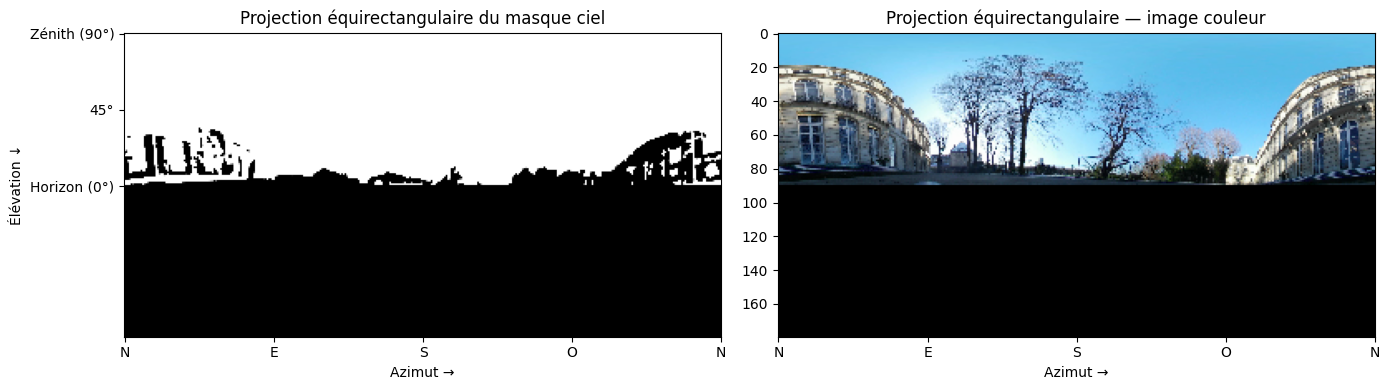

In [7]:
# Reconstruction du masque plein format (noir à gauche si single-right)
if fmt == 'right':
    full_mask = np.concatenate(
        [np.zeros((h, w_half), dtype=np.uint8), sky_mask], axis=1
    )
else:
    full_mask = np.concatenate(
        [sky_mask, np.zeros((h, w_half), dtype=np.uint8)], axis=1
    )

eq = dual_fisheye_to_equirectangular(
    full_mask, out_h=180, out_w=360, fov_deg=180,
    single_half=fmt if fmt in ('left','right') else None,
)
eq.rotate(delta_azimuth=0.0, delta_inclination=np.deg2rad(0))

print(f'Carte équirectangulaire : {eq.array.shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lum = eq.luminance()
axes[0].imshow(lum, cmap='gray', aspect='auto')
axes[0].set_title('Projection équirectangulaire du masque ciel')
axes[0].set_xlabel('Azimut →')
axes[0].set_ylabel('Élévation ↓')
axes[0].set_xticks(np.linspace(0, 360, 5))
axes[0].set_xticklabels(['N', 'E', 'S', 'O', 'N'])
axes[0].set_yticks([0, 45, 90])
axes[0].set_yticklabels(['Zénith (90°)', '45°', 'Horizon (0°)'])

# Image couleur reprojetée pour comparaison
eq_color = dual_fisheye_to_equirectangular(
    img_rgb, out_h=180, out_w=360, fov_deg=180,
    single_half=fmt if fmt in ('left','right') else None,
)
eq_color.rotate(delta_azimuth=0.0, delta_inclination=np.deg2rad(0))
axes[1].imshow(eq_color.array, aspect='auto')
axes[1].set_title('Projection équirectangulaire — image couleur')
axes[1].set_xlabel('Azimut →')
axes[1].set_xticks(np.linspace(0, 360, 5))
axes[1].set_xticklabels(['N', 'E', 'S', 'O', 'N'])

plt.tight_layout()
plt.show()

## 5. Profil d'horizon extrait

In [8]:
horizon = get_horizon_from_sphere(eq)
horizon_deg = np.rad2deg(horizon)

print(f'Profil : {len(horizon)} valeurs')
print(f'Élévation min : {horizon_deg.min():.1f}°')
print(f'Élévation max : {horizon_deg.max():.1f}°')
print(f'Élévation moy : {horizon_deg.mean():.1f}°')

Profil : 360 valeurs
Élévation min : 1.0°
Élévation max : 31.0°
Élévation moy : 5.5°


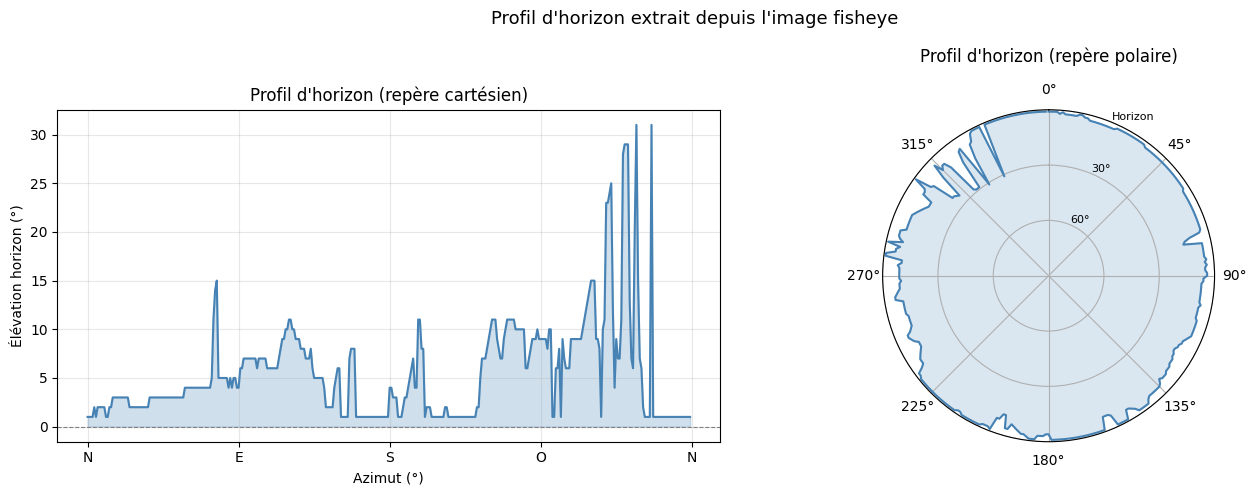

In [9]:
azimuths = np.arange(360)

fig = plt.figure(figsize=(14, 5))

# Cartésien
ax1 = fig.add_subplot(1, 2, 1)
ax1.fill_between(azimuths, horizon_deg, alpha=0.25, color='steelblue')
ax1.plot(azimuths, horizon_deg, color='steelblue', lw=1.5)
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.set_xlabel('Azimut (°)')
ax1.set_ylabel('Élévation horizon (°)')
ax1.set_title('Profil d\'horizon (repère cartésien)')
ax1.set_xticks([0, 90, 180, 270, 360])
ax1.set_xticklabels(['N', 'E', 'S', 'O', 'N'])
ax1.grid(True, alpha=0.3)

# Polaire
ax2 = fig.add_subplot(1, 2, 2, projection='polar')
theta_rad = np.deg2rad(azimuths)
r_vals    = 90.0 - horizon_deg
ax2.plot(theta_rad, r_vals, color='steelblue', lw=1.5)
ax2.fill(theta_rad, r_vals, alpha=0.2, color='steelblue')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_rlim(0, 90)
ax2.set_rticks([30, 60, 90])
ax2.set_yticklabels(['60°', '30°', 'Horizon'], fontsize=8)
ax2.set_title('Profil d\'horizon (repère polaire)', pad=15)

plt.suptitle('Profil d\'horizon extrait depuis l\'image fisheye', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Pipeline en une ligne + export du cache

In [10]:
# compute_horizon_from_image gère automatiquement tout ce qui précède
horizon_real = compute_horizon_from_image(
    image_path      = IMAGE_PATH,
    fov_deg         = 180,
    single_half     = None,   # auto-détection
    azimuth_deg     = 0.0,
    inclination_deg = 0.0,
)

# Création d'un horizon différent pour la cible ---
# Imaginons que la façade cible "voit" un grand bâtiment de 40° à l'Est (de 60° à 120°)
# que le capteur sur le toit ne voit pas.
horizon_virtual = np.copy(horizon_real)
horizon_virtual[60:120] = np.maximum(horizon_virtual[60:120], np.deg2rad(40))

# Sauvegarde du cache avec les deux horizons !
cache_path = ROOT / 'data' / 'horizon_profile.json'
with open(cache_path, 'w') as f:
    json.dump({
        'horizon_real': horizon_real.tolist(),
        'horizon_virtual_1': horizon_virtual.tolist()
    }, f)

print(f'Cache sauvegardé avec horizons multiples : {cache_path}')

Cache sauvegardé avec horizons multiples : C:\Users\OMAR\Desktop\Solar\data\horizon_profile.json
